Генерация фазовой карты для I = 8.88 мкА/см²
Расчет карты спайков для начальных условий...


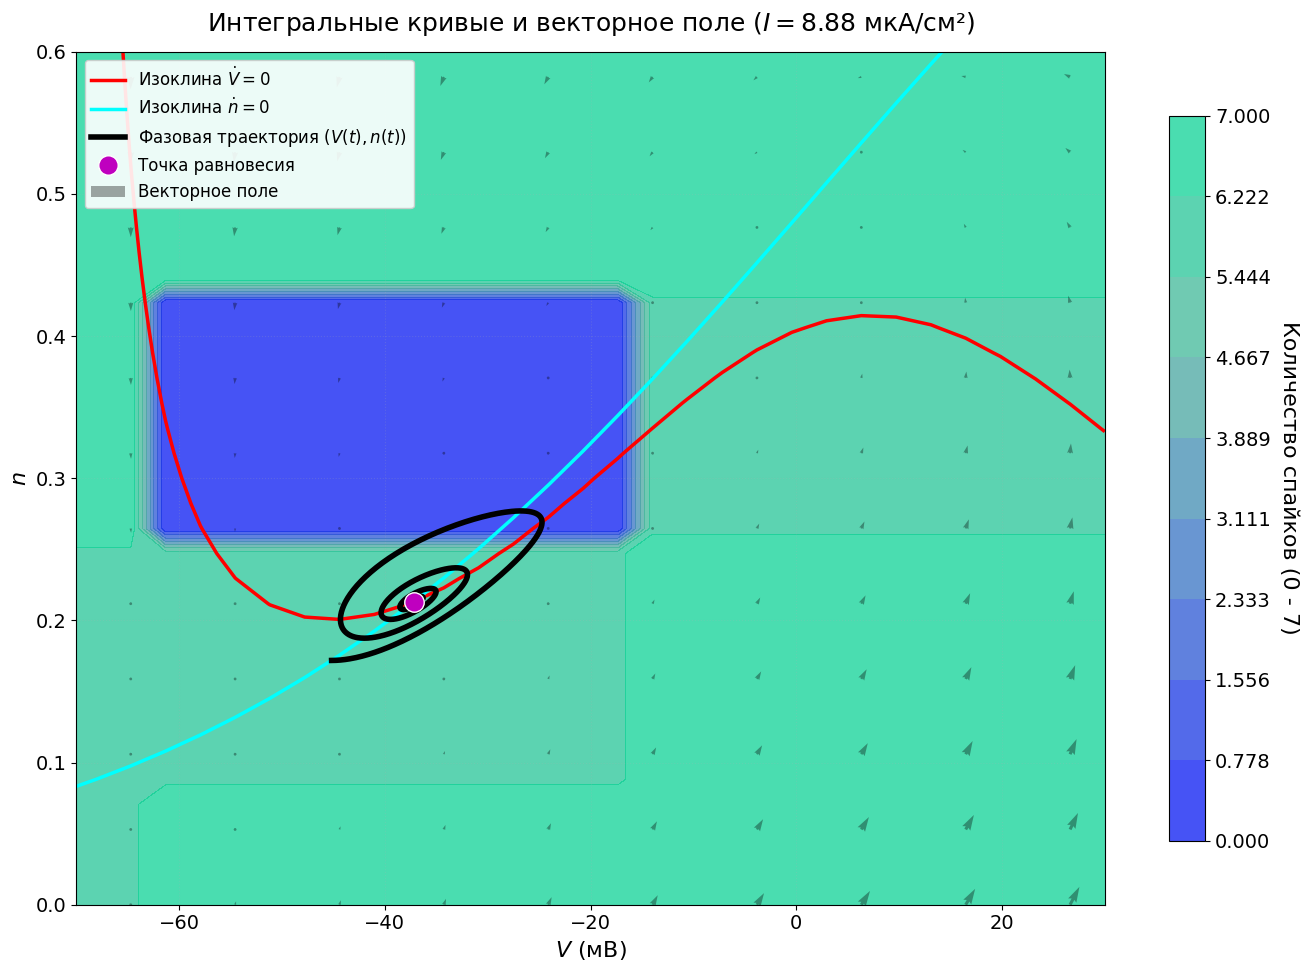

Равновесие: V_eq=-37.18 мВ, n_eq=0.213
tr(J)=-0.011, det(J)=0.002
Моделирование одномерного среза при фиксированном n = 0.05...


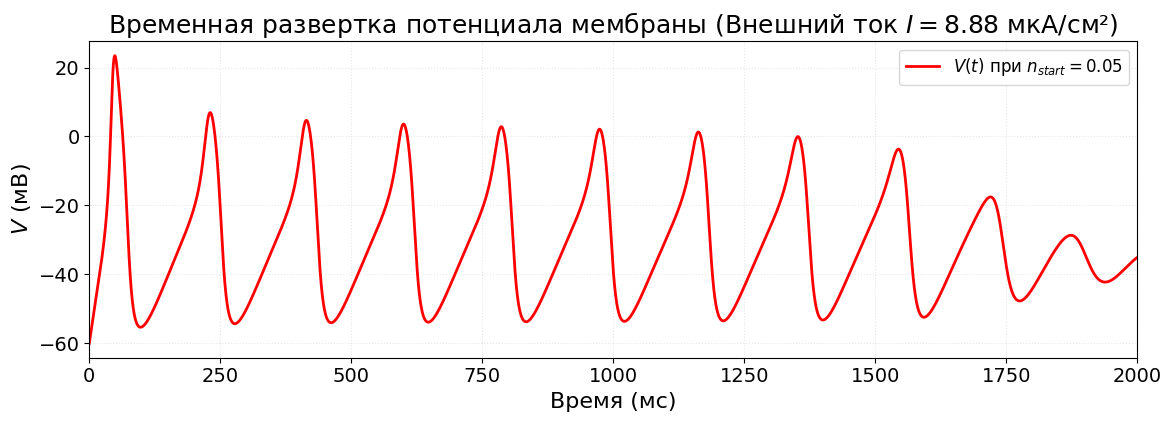

In [1]:
"""
Morris-Lecar Model: Advanced Phase Plane Map with Spike Basins and Vector Field.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.signal import find_peaks
from matplotlib.colors import LinearSegmentedColormap

# Глобальная настройка шрифтов высокого разрешения для GitHub/публикаций
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
})

# Параметры модели Морриса-Лекара
PARAMS = {
    'C': 20.0, 'g_leak': 0.20, 'V_leak': -50.0,
    'g_Ca': 4.4, 'V_Ca': 100.0, 'g_K': 8.0, 'V_K': -70.0,
    'V1': -1.0, 'V2': 15.0, 'V3': 2.0, 'V4': 30.0, 'phi': 0.05
}

def inf_m(V):
    return 1 / (1 + np.exp((PARAMS['V1'] - V) / PARAMS['V2']))

def inf_n(V):
    return 1 / (1 + np.exp((PARAMS['V3'] - V) / PARAMS['V4']))

def inf_Veq(V, I_hold):
    """Стационарная функция для поиска точек покоя (ОДУ = 0)."""
    m_inf = inf_m(V)
    n_inf = inf_n(V)
    I_leak = PARAMS['g_leak'] * (V - PARAMS['V_leak'])
    I_Ca = PARAMS['g_Ca'] * m_inf * (V - PARAMS['V_Ca'])
    I_K = PARAMS['g_K'] * n_inf * (V - PARAMS['V_K'])
    return (-I_leak - I_Ca - I_K + I_hold) / PARAMS['C']

def morris_lecar(t, y, I):
    """Система ОДУ Морриса-Лекара."""
    V, n = y
    I_leak = PARAMS['g_leak'] * (V - PARAMS['V_leak'])
    I_Ca = PARAMS['g_Ca'] * inf_m(V) * (V - PARAMS['V_Ca'])
    I_K = PARAMS['g_K'] * n * (V - PARAMS['V_K'])
    dVdt = (-I_leak - I_Ca - I_K + I) / PARAMS['C']
    dn_dt = PARAMS['phi'] * (inf_n(V) - n)
    return [dVdt, dn_dt]

def DBolt(V5, V, k):
    return np.exp((V5 - V) / k) / (k * (1 + np.exp((V5 - V) / k))**2)

def trJ(V):
    m_inf = inf_m(V)
    n_inf = inf_n(V)
    Dm_inf = DBolt(PARAMS['V1'], V, PARAMS['V2'])
    return -PARAMS['phi'] - (PARAMS['g_leak'] + PARAMS['g_K'] * n_inf +
             PARAMS['g_Ca'] * (m_inf + Dm_inf * (V - PARAMS['V_Ca']))) / PARAMS['C']

def detJ(V):
    m_inf = inf_m(V)
    n_inf = inf_n(V)
    Dm_inf = DBolt(PARAMS['V1'], V, PARAMS['V2'])
    Dn_inf = DBolt(PARAMS['V3'], V, PARAMS['V4'])
    return (PARAMS['g_leak'] + PARAMS['g_K'] * (n_inf + Dn_inf * (V - PARAMS['V_K'])) +
            PARAMS['g_Ca'] * (m_inf + Dm_inf * (V - PARAMS['V_Ca']))) / PARAMS['C'] * PARAMS['phi']

# Указываем входной ток глобально
I_IN = 8.88

def plot_phase_plane(I=I_IN):
    print(f"Генерация фазовой карты для I = {I} мкА/см²")

    # Сетка фазового пространства
    V_range = np.linspace(-85, 30, 35)
    n_range = np.linspace(0, 0.6, 35)
    V_grid, n_grid = np.meshgrid(V_range, n_range)

    # 1. Расчет векторного поля (Quiver Grid)
    dVdt_grid = np.zeros_like(V_grid)
    dn_dt_grid = np.zeros_like(n_grid)
    for row in range(V_grid.shape[0]):
        for col in range(V_grid.shape[1]):
            derivs = morris_lecar(0, [V_grid[row, col], n_grid[row, col]], I)
            dVdt_grid[row, col] = derivs[0]
            dn_dt_grid[row, col] = derivs[1]

    # Изоклина V (функция токов для контура нулевого уровня)
    F_V = (-PARAMS['g_leak'] * (V_grid - PARAMS['V_leak'])
           - PARAMS['g_Ca'] * inf_m(V_grid) * (V_grid - PARAMS['V_Ca'])
           - PARAMS['g_K'] * n_grid * (V_grid - PARAMS['V_K']) + I)

    V_eq = fsolve(inf_Veq, -20.0, args=(I,))[0]
    n_eq = inf_n(V_eq)

    # Основная траектория со смещением от равновесия
    sol = solve_ivp(lambda t, y: morris_lecar(t, y, I),
                    [0, 1500], [V_eq - 8, inf_n(V_eq - 8)],
                    t_eval=np.linspace(0, 1500, 3000), rtol=1e-6)

    # 2. Вычисление карты бассейнов спайкинга
    print("Расчет карты спайков для начальных условий...")
    spike_map = np.zeros((len(n_range), len(V_range)))
    step_v, step_n = 14, 10
    max_spikes = 0
    t_span = [0, 2000]
    t_eval_spikes = np.linspace(0, 2000, 10000)

    for i in range(0, len(V_range), step_v):
        for j in range(0, len(n_range), step_n):
            V_start, n_start = V_range[i], n_range[j]
            try:
                sol_test = solve_ivp(lambda t, y: morris_lecar(t, y, I),
                                     t_span, [V_start, n_start], t_eval=t_eval_spikes,
                                     method='LSODA', rtol=1e-6)
                peaks, _ = find_peaks(sol_test.y[0][t_eval_spikes > 100], height=0, distance=50)
                n_spikes = len(peaks)
                max_spikes = max(max_spikes, n_spikes)

                # Заполнение блока карты вокруг вычисленного узла
                v_slice = slice(max(0, i - step_v//2), min(len(V_range), i + step_v//2 + 1))
                n_slice = slice(max(0, j - step_n//2), min(len(n_range), j + step_n//2 + 1))
                spike_map[n_slice, v_slice] = n_spikes
            except Exception:
                spike_map[j, i] = 0

    # Создание кастомного градиента цвета
    colors_custom = [(0/255, 11/255, 249/255), (0.2, 0.4, 0.8), (0.3, 0.7, 0.6), (1/255, 216/255, 149/255)]
    cmap_custom = LinearSegmentedColormap.from_list('custom_spikes', colors_custom)

    # --- СТРОИМ ФАЗОВУЮ ПЛОСКОСТЬ ---
    plt.figure(figsize=(14, 10))

    # Закраска бассейнов генерации импульсов
    levels_sp = np.linspace(0, max_spikes if max_spikes > 0 else 1, 10)
    plt.contourf(V_range, n_range, spike_map, levels=levels_sp, cmap=cmap_custom, alpha=0.75)
    cbar = plt.colorbar(shrink=0.85)
    cbar.set_label(f'Количество спайков (0 - {max_spikes})', rotation=270, labelpad=20)

    # Изоклины динамической системы (исправлено добавлением префикса r)
    plt.contour(V_grid, n_grid, F_V, levels=[0], colors='red', linewidths=2.5)
    plt.plot([], [], color='red', linewidth=2.5, label=r'Изоклина $\dot{V} = 0$')
    plt.plot(V_range, inf_n(V_range), color='cyan', linewidth=2.5, label=r'Изоклина $\dot{n} = 0$')

    # Траектория и особая точка
    plt.plot(sol.y[0], sol.y[1], 'k-', linewidth=4, label='Фазовая траектория $(V(t), n(t))$')
    plt.plot(V_eq, n_eq, 'mo', markersize=14, markeredgecolor='white', label='Точка равновесия')

    # Векторное поле направлений (Quiver)
    step = 3
    plt.quiver(V_grid[::step, ::step], n_grid[::step, ::step],
               dVdt_grid[::step, ::step] * 0.02, dn_dt_grid[::step, ::step] * 15,
               scale=30, width=0.003, color='black', alpha=0.35, label='Векторное поле')

    plt.xlabel('$V$ (мВ)')
    plt.ylabel('$n$')
    plt.title(f'Интегральные кривые и векторное поле ($I = {I}$ мкА/см²)', pad=15)
    plt.legend(loc='upper left', facecolor='white', framealpha=0.9)
    plt.grid(True, alpha=0.2, linestyle=':')
    plt.xlim(-70, 30)
    plt.ylim(0, 0.6)
    plt.tight_layout()
    plt.show()

    print(f"Равновесие: V_eq={V_eq:.2f} мВ, n_eq={n_eq:.3f}")
    print(f"tr(J)={trJ(V_eq):.3f}, det(J)={detJ(V_eq):.3f}")

    # --- СТРОИМ ОДНОМЕРНЫЙ СРЕЗ V(t) ---
    print("Моделирование одномерного среза при фиксированном n = 0.05...")
    n_fixed = 0.05
    sol_n05 = solve_ivp(lambda t, y: morris_lecar(t, y, I),
                        [0, 2000], [-60.0, n_fixed],
                        t_eval=np.linspace(0, 2000, 10000), method='LSODA', rtol=1e-6)

    plt.figure(figsize=(12, 4.5))
    plt.plot(sol_n05.t, sol_n05.y[0], 'r-', linewidth=2, label=f'$V(t)$ при $n_{{start}}={n_fixed}$')
    plt.title(f'Временная развертка потенциала мембраны (Внешний ток $I={I}$ мкА/см²)')
    plt.xlabel('Время (мс)')
    plt.ylabel('$V$ (мВ)')
    plt.grid(True, alpha=0.3, linestyle=':')
    plt.xlim(0, 2000)
    plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Безопасный вызов с использованием определенной константы
    plot_phase_plane(I_IN)